<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Samudra(CNN)/DLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries:

In [ ]:
!pip install kaggle tensorflow scikit-learn

Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')

# Add labels: 0 = fake, 1 = real
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df[['title','text','label']], true_df[['title','text','label']]], ignore_index=True)

# Combine title + text for better representation
df['text'] = df['title'] + ' ' + df['text']
df = df[['text','label']]

Mounted at /content/drive


Text Preprocessing

In [ ]:
import re
def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove non-alphabet characters
    text = text.lower().strip()
    return text

df['text'] = df['text'].apply(preprocess_text)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)


Tokenization & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 15000
max_len = 5000  # max words per news

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

Build Text CNN Model

In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5000, 128)      │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4996, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,018,689 (7.70 MB)

 Trainable params: 2,018,689 (7.70 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 65s 102ms/step - accuracy: 0.9127 - loss: 0.1870 - val_accuracy: 0.9994 - val_loss: 0.0019
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 96ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 1.0000 - loss: 1.9187e-04 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 96ms/step - accuracy: 1.0000 - loss: 1.0442e-04 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 5/10
435/562 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 1.0000 - loss: 3.1295e-05

KeyboardInterrupt: 

Evaluate Model

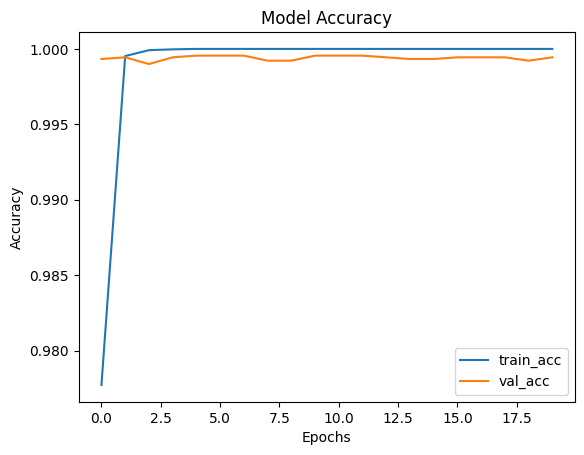

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Confusion Matrix:
 [[4732    1]
 [   4 4243]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Plot training history
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predictions & metrics
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Full Detection

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("📰 Fake News Detector")
print("Type 'exit' to quit.\n")

while True:
    # Ask user to enter news
    news_text = input("Enter news article: ")

    if news_text.lower() == "exit":
        print("Exiting the detector. Goodbye! 👋")
        break

    # Wrap in list (tokenizer expects a list)
    new_text = [news_text]

    # Tokenize + pad (same tokenizer and maxlen as training)
    new_seq = tokenizer.texts_to_sequences(new_text)
    new_padded = pad_sequences(new_seq, maxlen=50000)

    # Predict with trained CNN model
    prediction = model.predict(new_padded)

    # Show result
    if prediction[0][0] > 0.5:
        print("✅ This news is classified as REAL 📰")
    else:
        print("❌ This news is classified as FAKE 🚨")

    print("🔎 Confidence score:", float(prediction[0][0]))
    print("\n----------------------------\n")



📰 Fake News Detector
Type 'exit' to quit.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
✅ This news is classified as REAL 📰
🔎 Confidence score: 0.6127138733863831

----------------------------

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
❌ This news is classified as FAKE 🚨
🔎 Confidence score: 0.12523047626018524

----------------------------

